In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
from astropy.coordinates import angular_separation
import scienceplots
from os.path import exists
import seaborn as sns
import matplotlib as mpl

from astropy.cosmology import FlatLambdaCDM

import sys
sys.path.append("../")
from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

SPEED_OF_LIGHT = 299_792.458

In [2]:
def interp_dist2redshift(dist, Om0=0.3, zmin_interp=1e-6,
                         zmax_interp=0.1, npoints_interp=1000):
    cosmo = FlatLambdaCDM(H0=100, Om0=Om0)
    z_grid = np.linspace(zmin_interp, zmax_interp, npoints_interp)
    dist_grid = cosmo.comoving_distance(z_grid).value

    return np.exp(np.interp(np.log(dist), np.log(dist_grid), np.log(z_grid),
                            left=np.nan, right=np.nan))

In [4]:
!ls /mnt/extraspace/rstiskalek/catalogs/

2M++_galaxy_catalog.dat		 Lilow2024_yVelocity.npy
2M++_galaxy_catalog_descr.txt	 Lilow2024_zVelocity.npy
2M++_group_catalog.dat		 mcxc.fits
5asfullmatch.fits		 mdpl2_cosmic_time.txt
A2.h5				 MDPL2_FOF_125.hdf5
CF4				 nsa_v1_0_1.fits
CF4gp_new_64-z008_delta.fits	 PV
CF4gp_new_64-z008_velocity.fits  PV_compilation.hdf5
CMB				 PV_mock_CB2_17417_large.hdf5
diffmah_mdpl2.h5		 PV_mock_CB2_17417_small.hdf5
HAMLET				 TariqClusters.txt
HFI_PCCS_SZ-union_R2.08.fits	 twompp_density_carrick2015.npy
IndranilVoid			 twompp_velocity_carrick2015.npy
LEDA.hdf5			 unzip.py
Lilow2024_density.npy		 void_size_variation_target.7z
Lilow2024_xVelocity.npy


In [6]:
# fpath = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TF-distances.hdf5"
fpath = "/mnt/extraspace/rstiskalek/catalogs/PV_compilation.hdf5"

loader = csiborgtools.flow.DataLoader("Carrick2015", [0], "LOSS", fpath, paths, ksmooth=0, )

angdist = angular_separation(
    np.deg2rad(loader.cat["RA"]), np.deg2rad(loader.cat["DEC"]),
    np.deg2rad(csiborgtools.clusters["Virgo"].spherical_pos[1]),
    np.deg2rad(csiborgtools.clusters["Virgo"].spherical_pos[2]))
k = np.argmin(angdist)
print([loader.cat["RA"][k], loader.cat["DEC"][k]])
print(csiborgtools.clusters["Virgo"].spherical_pos[1:])
print(csiborgtools.clusters["Virgo"].spherical_pos[0])


2025-03-15 18:50:48,583 reading the catalogue,
2025-03-15 18:50:48,590 reading the interpolated field.
2025-03-15 18:50:48,607 calculating the radial velocity.
[186.158, 10.83817]
[186.75        12.71666667]
12.045


In [38]:
rgrid = loader.rdist
vel = loader.los_radial_velocity

from interpax import interp1d
from jax import vmap
from jax import numpy as jnp

def interpolate_los(r, los, rgrid, method="linear", which=None):
    """
    Interpolate the LOS field at a given radial distance.

    Parameters
    ----------
    r : 1-dimensional array of shape `(n_gal, )`
        Radial distances at which to interpolate the LOS field.
    los : 3-dimensional array of shape `(n_sims, n_gal, n_steps)`
        LOS field.
    rgrid : 1-dimensional array of shape `(n_steps, )`
        Radial distances at which the LOS field was interpolated.
    method : str, optional
        Interpolation method. Default is "linear".

    Returns
    -------
    2-dimensional array of shape `(n_sims, n_gal)`
    """
    # Vectorize over the inner loop (ngal) first, then the outer loop (nsim)
    def f(rn, los_row):
        if which == "radial_velocity":
            extrap = (los_row[0], los_row[-1] * jnp.sqrt((rgrid[-1] / rn)))
        elif which == "log_density":
            extrap = 0
        else:
            extrap = False

        return interp1d(rn, rgrid, los_row, method=method, extrap=extrap,)

    return vmap(vmap(f, in_axes=(0, 0)), in_axes=(None, 0))(r, los)

In [52]:
ngal = vel.shape[1]

r = np.ones(ngal) * 221.1

y = interpolate_los(r, vel, rgrid, )[0]

k = np.argmin(np.abs(rgrid - r[0]))

In [53]:
vel[0, :, k], y


(array([ -40.6569    ,  -51.056564  ,  -19.876549  ,   21.957058  ,
         -16.975117  ,  -14.165241  ,   22.577976  ,   89.1389    ,
        -246.47588   ,   11.144217  ,  -37.21972   , -171.98605   ,
          21.694056  ,   59.94999   ,  -63.46965   ,    1.5164938 ,
          16.58013   ,   39.02291   ,   19.708864  ,  122.43324   ,
         -48.36961   ,  -14.16582   ,  -31.899044  ,   15.058807  ,
          77.14005   ,   51.22168   ,   27.124964  ,   49.043674  ,
          72.01843   ,   28.566048  ,  -50.23192   ,   20.507673  ,
           0.52255535,  -49.629627  ,   77.138306  ,  -44.607533  ,
          92.77731   ,   11.875931  ,  -10.689747  ,   29.683985  ,
          -5.800413  ,  178.90997   ,  -28.45079   ,  176.06339   ,
         161.69205   ,   37.882637  ,   23.056293  ,   18.022522  ,
          39.33155   ,   32.606686  ], dtype=float32),
 Array([ -40.6926   ,  -50.94604  ,  -19.988075 ,   21.952095 ,
         -16.930775 ,  -14.124049 ,   22.567127 ,   88.720406 ,
 

In [54]:
vel[0, :, k] - y

Array([ 3.57017517e-02, -1.10523224e-01,  1.11526489e-01,  4.96292114e-03,
       -4.43420410e-02, -4.11920547e-02,  1.08489990e-02,  4.18495178e-01,
       -5.57250977e-02,  1.25427246e-02, -8.41140747e-03, -3.88793945e-02,
        9.85527039e-03,  7.22618103e-02, -1.97044373e-01, -1.00409985e-03,
        3.74794006e-03,  8.81958008e-03,  1.35154724e-02,  4.46937561e-01,
       -8.83979797e-02, -3.81917953e-02, -9.36126709e-02, -1.06811523e-04,
        9.60388184e-02,  2.82169342e-01,  6.13212585e-03,  1.14498138e-01,
        1.62811279e-02,  1.45322800e-01, -9.70306396e-02,  4.63485718e-03,
       -7.42727518e-03, -9.42001343e-02,  6.69326782e-02, -1.75807953e-01,
        4.78843689e-01,  1.10383987e-01, -1.11892700e-01,  7.04383850e-02,
       -1.31082535e-03,  4.04510498e-02, -6.76479340e-02,  3.86245728e-01,
        3.65600586e-02,  3.47709656e-02,  2.03037262e-02,  4.07409668e-03,
        8.89205933e-03,  2.30636597e-02], dtype=float32)

In [45]:
y

Array([ 181.45079  , -185.20644  ,  -65.97568  ,  324.60645  ,
        -28.255531 ,  -62.700806 , -182.33415  , -393.57907  ,
          6.9683676, -244.86174  ,  455.14957  ,   13.312185 ,
        225.87685  , -438.85107  ,   77.55071  , -236.99136  ,
        365.98862  , -600.5655   ,  -58.079746 ,   12.578135 ,
       -308.65076  ,  -61.836906 , -222.09927  ,  -89.71386  ,
       -538.0616   ,  -20.347586 ,  473.55087  , -253.95157  ,
        385.49606  ,  155.82619  , -247.98175  ,  104.97616  ,
       -206.0055   ,  -78.06827  ,  -71.90398  ,  159.4937   ,
       -128.64114  , -472.22092  ,  584.2141   ,  227.90802  ,
        581.4412   ,  633.07043  ,  -30.505358 ,   37.581345 ,
        390.46533  , -422.57584  , -332.23706  ,  330.73566  ,
        485.37665  , -310.12216  ], dtype=float32)

In [7]:
r = csiborgtools.clusters["Virgo"].cartesian_pos(100) - 50
r /= np.linalg.norm(r)
r

array([-0.96870904, -0.11465427,  0.22012997])

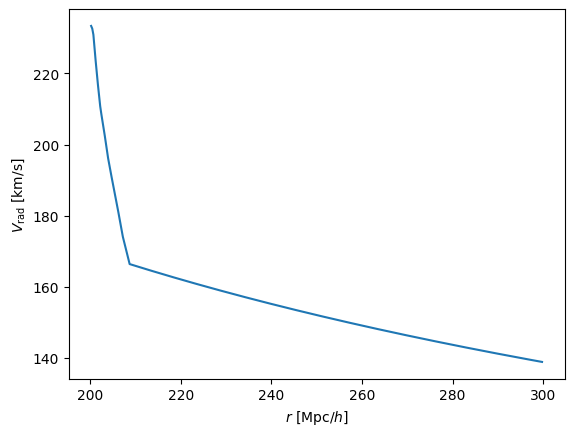

In [9]:
r = loader.rdist
vrad = loader.los_radial_velocity[0, k, :]

plt.figure()
m = r > 200
plt.plot(r[m], vrad[m])
plt.xlabel(r"$r ~ [\mathrm{Mpc} / h]$")
plt.ylabel(r"$V_{\mathrm{rad}} ~ [\mathrm{km/s}]$")
plt.show()

In [92]:
X = np.vstack([r, vrad]).T
np.savetxt("virgo_los.txt", X)

### Test Malmquis bias integral

In [92]:
from quadax import simpson
import jax

n = 50

loader = csiborgtools.flow.DataLoader("csiborg1", [0], "CF4_TFR_i", fpath, paths, ksmooth=0, )



2025-02-28 05:10:20   reading the catalogue,
2025-02-28 05:10:20   reading the interpolated field.
2025-02-28 05:10:22   calculating the radial velocity.


In [114]:
r = loader.rdist[:400]
rho = loader.los_density[0, ...][:, :400]

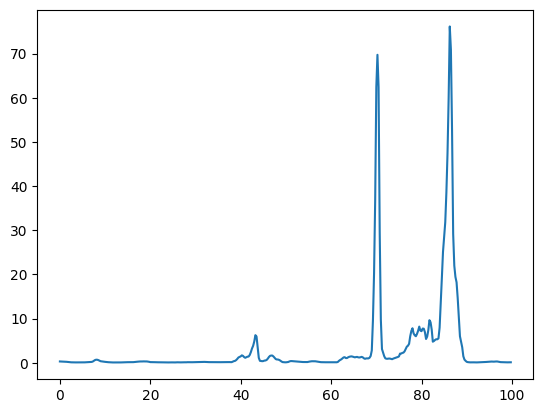

In [115]:
plt.figure()
plt.plot(r, rho[30])
plt.show()

In [116]:
@jax.jit
def malmquist_norm(r, rho, alpha):
    return simpson(r**2 * rho**alpha, x=r, axis=-1)

In [124]:
alpha = jnp.linspace(0., 2, 100)
y = jax.vmap(lambda alpha: malmquist_norm(r, rho, alpha))(alpha)


In [133]:
y /= y[0][None, :]

In [134]:
# y /= jnp.mean(y, axis=0)[None, :]

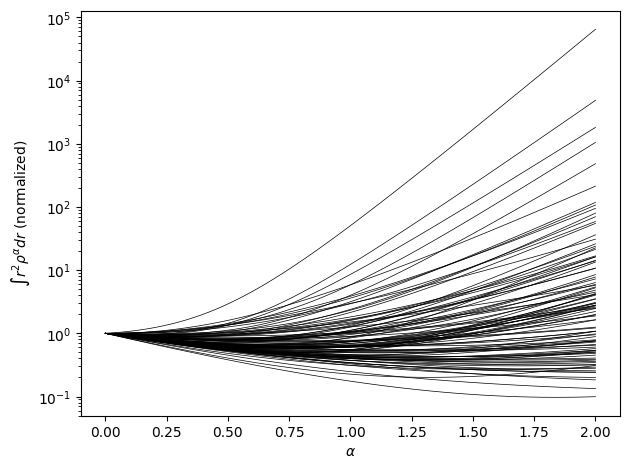

In [ ]:
plt.figure()
for n in range(100):
    plt.plot(alpha, y[:, n], color="k", lw=0.5)

plt.yscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\int r^2 \rho^\alpha dr$ (normalized)")
plt.tight_layout()
plt.show()

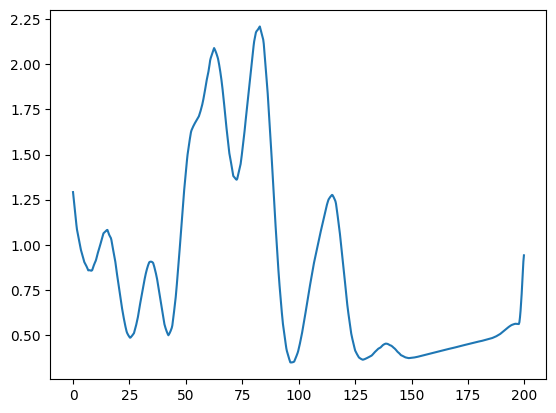

In [42]:
plt.figure()
plt.plot(r, rho)
plt.show()

In [ ]:
l